# Project Overview

The objective of this project is to automatically identify underlying themes in a large collection of BBC News articles without relying on predefined categories.

Using natural language processing techniques, we transform raw text into numerical representations and group similar articles based on their linguistic patterns. The goal is to evaluate how effectively classical text representation methods (TF-IDF) combined with clustering algorithms can reveal meaningful topic structures in short news summaries.

## Data loading, validation, and exploration

We load the dataset, validate schema, remove duplicates, inspect missing values, and parse publication dates.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/bbc_news.csv")
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [2]:
expected_cols = {"title", "pubDate", "guid", "link", "description"}
print("Columns:", df.columns.tolist())
print("Missing columns:", expected_cols - set(df.columns))
print("Dataset shape:", df.shape)

df.isna().sum().sort_values(ascending=False)

before = df.shape[0]

df = df.drop_duplicates(subset=["guid"])
df = df.drop_duplicates(subset=["link"])

after = df.shape[0]

print("Rows before:", before)
print("Rows after:", after)
print("Removed duplicates:", before - after)

df["pubDate"] = pd.to_datetime(df["pubDate"], errors="coerce", utc=True)

print("Invalid dates:", df["pubDate"].isna().sum())
print("Date range:", df["pubDate"].min(), "->", df["pubDate"].max())

Columns: ['title', 'pubDate', 'guid', 'link', 'description']
Missing columns: set()
Dataset shape: (42115, 5)
Rows before: 42115
Rows after: 37850
Removed duplicates: 4265
Invalid dates: 0
Date range: 2013-08-30 01:01:55+00:00 -> 2024-12-04 00:05:52+00:00


Following data cleaning and deduplication, the dataset was reduced to more than 37,000 unique BBC News articles.

## Text construction, cleaning, and length analysis

We combine title and description, clean text, compute document lengths, and remove extreme cases because text clustering is sensitive to noise and document length.

In [3]:
df["title"] = df["title"].fillna("")
df["description"] = df["description"].fillna("")

df["text_raw"] = (df["title"] + ". " + df["description"]).str.strip()
df[["title", "description", "text_raw"]].head()

,title,description,text_raw
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...,Ukraine: Angry Zelensky vows to punish Russian...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as...",War in Ukraine: Taking cover in a town under a...
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...,Ukraine war 'catastrophic for global food'. On...
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...,Manchester Arena bombing: Saffie Roussos's par...
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...,Ukraine conflict: Oil price soars to highest l...


In [4]:
import re

def clean_text(s):
    s = s.lower()
    s = re.sub(r"http\S+", " ", s)
    s = re.sub(r"&\w+;", " ", s)
    s = re.sub(r"[^a-z\s']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_clean"] = df["text_raw"].apply(clean_text)
df["text_clean"].head()

df["n_chars"] = df["text_clean"].str.len()
df = df[df["n_chars"] >= 30].copy()

df.shape

(37850, 8)

In [5]:
df["n_tokens"] = df["text_clean"].apply(lambda x: len(x.split()))
df["n_tokens"].describe()

count    37850.000000
mean        27.230198
std          5.078218
min          5.000000
25%         24.000000
50%         26.000000
75%         29.000000
max         55.000000
Name: n_tokens, dtype: float64

Document length analysis shows that the news are short, with an average of approximately 27 tokens per document. The distribution is relatively tight, indicating consistent summary length across articles.

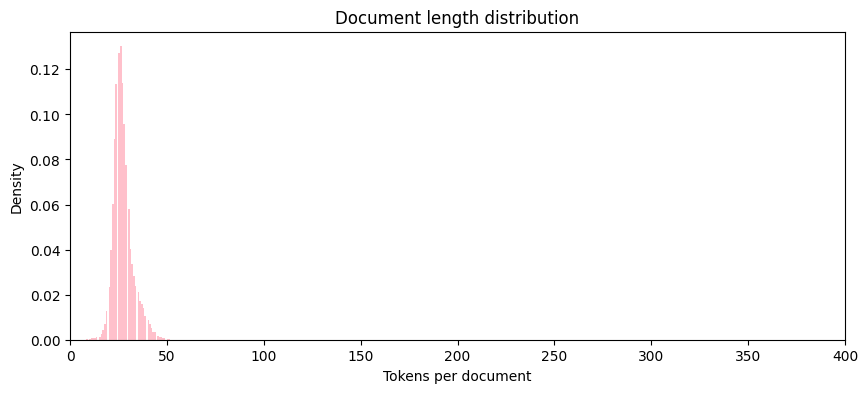

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(df["n_tokens"], bins=60, density=True, color="pink")
plt.xlabel("Tokens per document")
plt.ylabel("Density")
plt.title("Document length distribution")
plt.xlim(0,400)
plt.show()

The histogram shows that the document lengths are tightly concentrated, with the majority of news summaries containing between approximately 20 and 40 tokens.
This confirms that the dataset consists of short news summaries rather than full-length articles.

--------------------------------------------------------------------------------

We remove documents with fewer than 15 tokens to reduce noise in the TF-IDF representation.

In [7]:
df = df[df["n_tokens"] >= 15].copy()

df.shape

(37710, 9)

## Feature engineering with TF-IDF

We build multiple TF-IDF representations and compare vocabulary sizes.

**TF-IDF (Unigrams)**

We convert cleaned news summaries into TF-IDF vectors using unigrams (single words).

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_uni = TfidfVectorizer(
    stop_words="english",
    min_df=10,
    max_df=0.9
)
X_uni = tfidf_uni.fit_transform(df["text_clean"])
X_uni.shape

(37710, 7608)

**TF-IDF (Unigrams + Bigrams)**

We build another TF-IDF representation that includes both unigrams and bigrams (two-word phrases).

In [9]:
tfidf_bi = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=10,
    max_df=0.9
)

X_bi = tfidf_bi.fit_transform(df["text_clean"])
X_bi.shape

(37710, 10616)

**Vocabulary comparison**

In [10]:
pd.DataFrame({
    "Variant": ["Unigram", "Unigram + Bigram"],
    "Vocabulary size": [
        len(tfidf_uni.get_feature_names_out()),
        len(tfidf_bi.get_feature_names_out())
    ]
})

,Variant,Vocabulary size
0,Unigram,7608
1,Unigram + Bigram,10616


To better understand what information is captured by bigrams, we inspect the most informative bigram features based on their IDF values.

In [11]:
feature_names = tfidf_bi.get_feature_names_out()
idf_scores = tfidf_bi.idf_

idf_df = pd.DataFrame({
    "feature": feature_names,
    "idf": idf_scores
})

bigram_idf = idf_df[idf_df["feature"].str.contains(" ")]

bigram_idf.sort_values("idf", ascending=False).head(15)

,feature,idf
10562,years death,9.139812
52,accused failing,9.139812
10558,year world,9.139812
10555,year sentence,9.139812
10606,zharnel hughes,9.139812
9826,ukraine dam,9.139812
3150,ex soldier,9.139812
3144,ex girlfriend,9.139812
3254,facebook instagram,9.139812
3251,face england,9.139812


The bigrams with the highest IDF values correspond to very rare and highly specific phrases, including named individuals, isolated events, and mechanically formed word pairs (e.g., “years death”).

## Choosing the number of clusters

We estimate the best number of clusters using inertia (elbow) and silhouette score. To reduce runtime, we train MiniBatchKMeans and compute silhouette on a random subset of documents.

**Compute metrics**

In [12]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

Ks = range(4, 16)
inertias = []
silhouettes = []

rng = np.random.RandomState(42)
sample_size = min(5000, X_bi.shape[0])
sample_idx = rng.choice(X_bi.shape[0], size=sample_size, replace=False)
X_sample = X_bi[sample_idx]

for k in Ks:
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=2048,
        n_init=3,
        max_iter=200
    )
    labels = km.fit_predict(X_bi)

    inertias.append(km.inertia_)

    sil = silhouette_score(X_sample, labels[sample_idx], metric="cosine")
    silhouettes.append(sil)

results = pd.DataFrame({
    "k": list(Ks),
    "Inertia": inertias,
    "Silhouette": silhouettes
})

results

,k,Inertia,Silhouette
0,4,37278.421960,0.004173
1,5,37328.250586,0.003368
2,6,37155.722380,0.005260
3,7,37077.808873,0.007478
4,8,37017.629088,0.008153
5,9,36957.095177,0.009307
6,10,36974.290556,0.008530
7,11,36875.221932,0.010020
8,12,36890.416108,0.009012
9,13,36834.655269,0.010577


As the number of clusters increases, inertia steadily decreases, which indicates that documents become closer to their assigned cluster centers.
This behavior is expected, as using more clusters allows for finer partitioning of the data.

Silhouette scores are low because the documents are short news summaries with limited context.
Many articles share similar vocabulary across different topics, which leads to overlapping clusters.
In such short-text settings, low silhouette values are expected and do not indicate a failure of the clustering method.

**Plot Elbow**

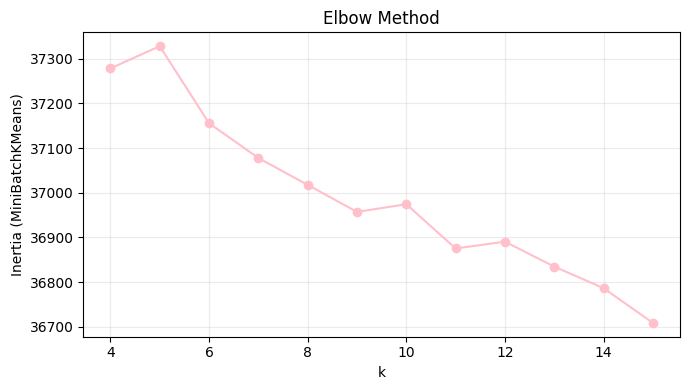

In [13]:
plt.figure(figsize=(7,4))
plt.plot(list(Ks), inertias, marker="o", color="pink")
plt.xlabel("k")
plt.ylabel("Inertia (MiniBatchKMeans)")
plt.title("Elbow Method")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

**Plot Silhouette**

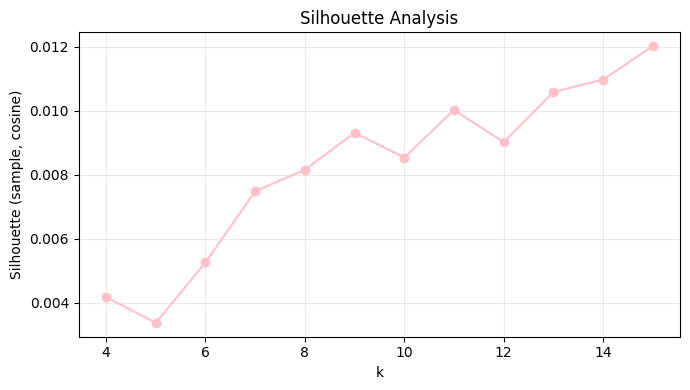

In [14]:
plt.figure(figsize=(7,4))
plt.plot(list(Ks), silhouettes, marker="o", color="pink")
plt.xlabel("k")
plt.ylabel("Silhouette (sample, cosine)")
plt.title("Silhouette Analysis")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

The plots help us choose a reasonable number of clusters instead of relying on a single metric.

## Clustering and diagnostics

We train the final clustering model using MiniBatchKMeans, assign cluster labels, and compute distances to cluster centroids for diagnostics and representative examples.

**Train final model**

In [15]:
from sklearn.cluster import MiniBatchKMeans

k = 11

kmeans = MiniBatchKMeans(
    n_clusters=k,
    random_state=42,
    batch_size=2048,
    n_init=10,
    max_iter=300
)
df["cluster"] = kmeans.fit_predict(X_bi)
df["cluster"].value_counts().sort_index()


cluster
0      1184
1      2135
2      1981
3       931
4       962
5      1976
6     22362
7      1826
8      1672
9      1863
10      818
Name: count, dtype: int64

The cluster size distribution is uneven, with one large cluster and several smaller clusters.
This pattern is expected in news data, where a large number of articles cover general or mixed topics, while smaller clusters correspond to more specific themes.

**Distance to centroid**

The distance to centroid measures how close a document is to the center of its cluster.
Smaller values indicate more representative documents.

In [16]:
from sklearn.metrics import pairwise_distances

D = pairwise_distances(X_bi, kmeans.cluster_centers_, metric="cosine")
df["dist_to_centroid"] = D[np.arange(len(df)), df["cluster"]]

**Cluster statistics table**

In [17]:
cluster_stats = (
    df.groupby("cluster")
      .agg(
          articles=("cluster", "count"),
          avg_tokens=("n_tokens", "mean"),
          median_tokens=("n_tokens", "median"),
          avg_dist=("dist_to_centroid", "mean"),
          median_dist=("dist_to_centroid", "median")
      )
      .sort_index()
)

cluster_stats

,articles,avg_tokens,median_tokens,avg_dist,median_dist
cluster,,,,,
0,1184,28.991554,28.0,0.827500,0.852860
1,2135,26.322248,26.0,0.816661,0.829347
2,1981,25.866734,26.0,0.837640,0.850074
3,931,29.340494,28.0,0.825538,0.833528
4,962,26.501040,26.0,0.740315,0.755230
5,1976,33.113360,33.0,0.738394,0.765623
6,22362,26.425856,26.0,0.936712,0.939317
7,1826,27.174699,27.0,0.831280,0.842367
8,1672,25.977273,26.0,0.729121,0.737263


We compute summary statistics for each cluster, including the number of articles, average document length, and average distance to the cluster centroid.

**Cluster size plot**

We visualize the number of articles assigned to each cluster using a bar chart.

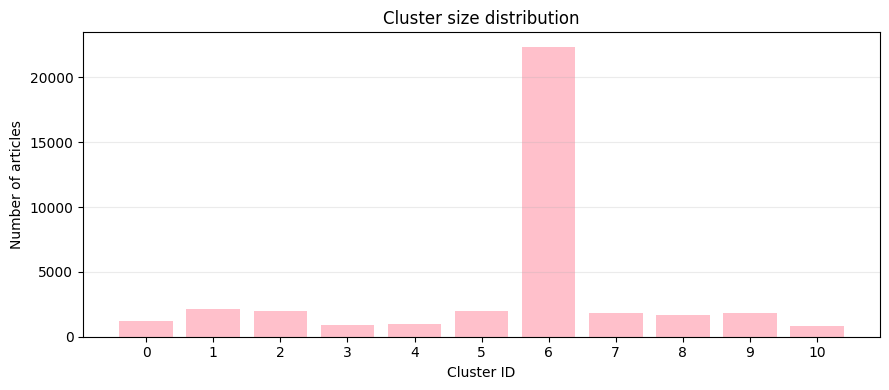

In [18]:
counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(9,4))
plt.bar(counts.index.astype(str), counts.values, color="pink")
plt.xlabel("Cluster ID")
plt.ylabel("Number of articles")
plt.title("Cluster size distribution")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

The plot shows a highly uneven distribution of cluster sizes.
One cluster contains a large proportion of the articles, while the remaining clusters are significantly smaller.
This pattern is typical for news data, where many articles cover broad or general topics, and fewer articles focus on more specific subjects.

**Representative and outlier examples per cluster**

For each cluster, we display the most representative articles (those closest to the cluster centroid) as well as the hardest cases or outliers (those farthest from the centroid).
This comparison helps interpret cluster themes and highlights documents that do not clearly fit into a single topic.

In [19]:
pd.set_option("display.max_colwidth", None)

def show_representatives(cluster_id, n=2):
    sample = (
        df[df["cluster"] == cluster_id]
        .sort_values("dist_to_centroid", ascending=True)
        .head(n)
        .copy()
    )
    sample["type"] = "representative"
    return sample[["cluster", "type", "title", "dist_to_centroid"]]

def show_outliers(cluster_id, n=2):
    sample = (
        df[df["cluster"] == cluster_id]
        .sort_values("dist_to_centroid", ascending=False)
        .head(n)
        .copy()
    )
    sample["type"] = "outlier"
    return sample[["cluster", "type", "title", "dist_to_centroid"]]

In [20]:
rows = []

for c in sorted(df["cluster"].unique()):
    reps = show_representatives(c, n=2)
    outs = show_outliers(c, n=2)
    rows.append(pd.concat([reps, outs], axis=0))

examples_per_cluster = pd.concat(rows, axis=0)

type_order = {"representative": 0, "outlier": 1}
examples_per_cluster["type_order"] = examples_per_cluster["type"].map(type_order)

examples_per_cluster = (
    examples_per_cluster
    .sort_values(["cluster", "type_order", "dist_to_centroid"])
    .drop(columns="type_order")
)

examples_per_cluster

,cluster,type,title,dist_to_centroid
6457,0,representative,Commonwealth Games: Delicious Orie wins gold for England,0.570790
36995,0,representative,GB win six medals on day three of Paris Olympics,0.581010
27892,0,outlier,Wolverhampton grandmother’s abusers caught by hidden camera,0.915874
36838,0,outlier,'Nothing can break me now' - Biles on what really happened in Tokyo,0.915920
9622,1,representative,Rishi Sunak’s cabinet: Who is in the prime minister’s top team?,0.556637
9584,1,representative,Rishi Sunak announced as next UK prime minister,0.561850
15615,1,outlier,Coronation carriage will be a more comfortable ride,0.911286
37365,1,outlier,Eluned Morgan to officially become first minister,0.913823
6534,2,representative,Cost of living: The people using OnlyFans as a second job to help with bills,0.482150
10271,2,representative,Cost of living and rent 'recipe for disaster for young people',0.512173


Based on the representative articles shown above, we can assign a simple topic title to each cluster.
The titles are chosen manually using the two most representative articles, which best describe the main topic of each cluster.

In the next step, we will compare these manually assigned titles with the top words extracted from each cluster.

0  - Olympic & International Sports

1  - UK Prime Minister & Government

2  - Cost of Living & Household Finances

3  - Society, Culture & Social Issues

4  - Israel-Gaza Conflict

5  - World Cup & International Football

6  - General News, Deaths & Incidents

7  - BBC & Media

8  - War in Ukraine

9  - UK Football Leagues

10 - Crime, Deaths & Investigations

## Interpretation, visualization, and error analysis

**Top terms per cluster**

To further interpret the discovered clusters, we examine the most important TF-IDF terms for each cluster.

In [21]:
terms = np.array(tfidf_bi.get_feature_names_out())

for c in range(k):
    top_idx = kmeans.cluster_centers_[c].argsort()[::-1][:15]
    print(f"\nCluster {c} top terms:")
    print(", ".join(terms[top_idx]))


Cluster 0 top terms:
home, gold, paris, games, commonwealth, britain, great britain, commonwealth games, championships, great, wins, gb, olympics, win, olympic

Cluster 1 top terms:
papers, sunak, king, pm, rishi, rishi sunak, labour, minister, new, prime, prime minister, starmer, charles, johnson, king charles

Cluster 2 top terms:
people, cost, living, cost living, energy, bills, says, say, young, uk, young people, help, rising, crisis, food

Cluster 3 top terms:
time, stars, champion, says, game, world, years, england, win, final, time years, carpet, second, red carpet, open

Cluster 4 top terms:
israel, gaza, hamas, israeli, war, israel gaza, says, killed, attack, ceasefire, hostages, hezbollah, palestinian, gaza war, aid

Cluster 5 top terms:
england, cup, world cup, world, final, women, win, women world, australia, test, euro, wales, zealand, new zealand, france

Cluster 6 top terms:
says, uk, police, new, say, years, man, trump, year, week, world, government, star, election, wo

The top TF-IDF terms strongly align with the manually assigned cluster titles.
Sports-related clusters contain terms such as games, olympics, world cup, and league, while political clusters are dominated by names of political leaders and government-related words.

--------------------------------------------------------------------------------

**2D Visualization of clusters**

To better understand the clustering results, we visualize the documents in two dimensions.
Since TF-IDF vectors are high-dimensional, we first reduce their dimensionality and then plot the articles in a 2D space.

In [22]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_bi)

X_2d.shape

(37710, 2)

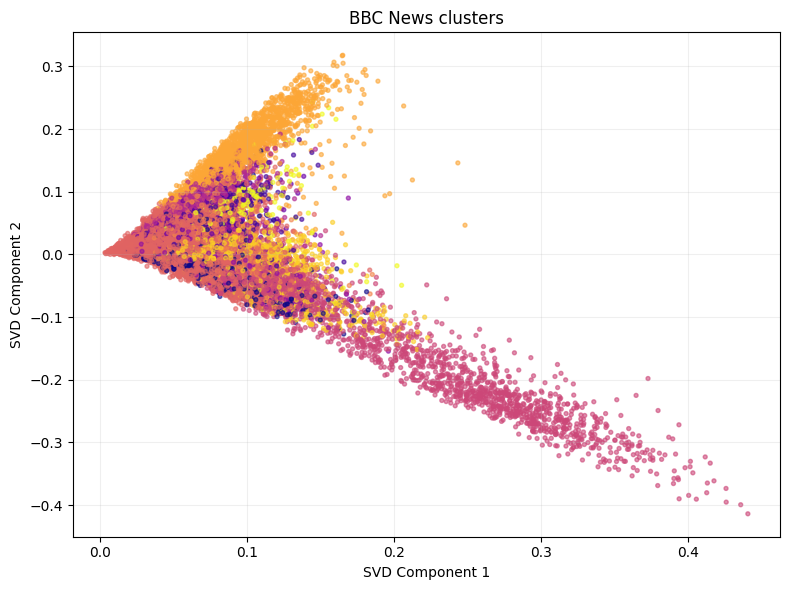

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=df["cluster"], s=8, alpha=0.6, cmap="plasma")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("BBC News clusters")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

The scatter plot shows a strong overlap between clusters, which is expected for short news texts.
Many articles share similar vocabulary and often cover multiple related topics.

This overlap explains the relatively low silhouette scores observed earlier.

**Silhouette analysis**

In [24]:
from sklearn.metrics import silhouette_samples
import numpy as np

rng = np.random.RandomState(42)
sample_size = min(5000, X_bi.shape[0])
sample_idx = rng.choice(X_bi.shape[0], size=sample_size, replace=False)

sil_vals = silhouette_samples(
    X_bi[sample_idx],
    df["cluster"].values[sample_idx],
    metric="cosine"
)

df["silhouette_sample"] = np.nan
df.loc[df.index[sample_idx], "silhouette_sample"] = sil_vals

df["silhouette_sample"].describe()

count    5000.000000
mean        0.009919
std         0.027692
min        -0.039251
25%        -0.005478
50%        -0.001359
75%         0.020035
max         0.176174
Name: silhouette_sample, dtype: float64

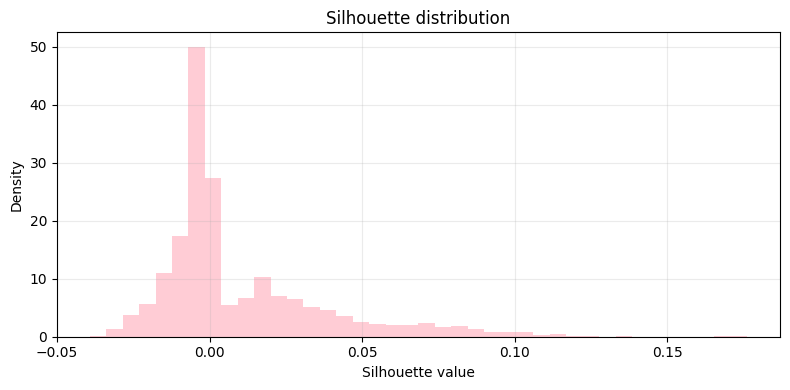

In [25]:
plt.figure(figsize=(8,4))
plt.hist(df["silhouette_sample"].dropna(), bins=40, density=True, color="pink", alpha=0.8)
plt.xlabel("Silhouette value")
plt.ylabel("Density")
plt.title("Silhouette distribution")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

The silhouette distribution is centered around zero, with most values being slightly positive or slightly negative.
This indicates that many articles lie close to cluster boundaries and share vocabulary with multiple topics.

Only a small fraction of documents achieve higher silhouette values, meaning they are clearly assigned to a single cluster.
Negative silhouette values correspond to ambiguous articles, which is expected in short news texts that often combine several themes.

**Error analysis using extreme silhouette scores**

In this section, we analyze documents with the lowest and highest silhouette scores.
We display full article titles to better understand which types of news are difficult to cluster and which are clearly assigned to a single topic.

Lowest Silhouette scores:

In [26]:
pd.set_option("display.max_colwidth", None)
df.dropna(subset=["silhouette_sample"]).sort_values("silhouette_sample").head(10)[
    ["silhouette_sample", "cluster", "title"]
]

,silhouette_sample,cluster,title
21779,-0.039251,6,WW2 Bletchley Park codebreaker dies aged 99
34953,-0.037089,6,Historic writer's desk could be 'knackered' old fake
39730,-0.035966,6,Doctor pleads guilty in Matthew Perry overdose death
19092,-0.034946,6,Watch: Mexican mayor weds crocodile in harvest ritual
39452,-0.034039,6,Putin proposes new rules for using nuclear weapons
10098,-0.032486,6,Why an old train could point to a clean energy future
40846,-0.032448,6,"Sara Sharif was innocent soul, murder accused said"
19918,-0.032292,6,KyivPride: Thousands march in Ukraine Pride in Liverpool
31307,-0.032235,6,Olly Alexander rejects call to boycott Eurovision
633,-0.032039,6,"'I sent my brother flak jackets, helmets and boots'"


Highest Silhouette scores:

In [27]:
pd.set_option("display.max_colwidth", None)
df.dropna(subset=["silhouette_sample"]).sort_values("silhouette_sample", ascending=False).head(10)[
    ["silhouette_sample", "cluster", "title"]
]

,silhouette_sample,cluster,title
28207,0.176174,10,Family of four found dead at house near Norwich
8879,0.175788,10,Thai nursery attack: The story of the three-year-old survivor
6552,0.170689,10,Thornton Heath explosion: Girl's death investigated by crime unit
30252,0.166408,10,Three charged over death of two-year-old boy
7531,0.140408,10,Olivia Pratt-Korbel: Arrests over nine-year-old's murder
10282,0.137614,5,T20 World Cup: How England turned it around to reach World Cup final against Pakistan
38352,0.137385,10,Teenage boy convicted of 15-year-old Holly Newton's murder
24166,0.136889,4,Israel-Gaza: Explosions pierce Gaza darkness as Israel steps up bombing
1213,0.128848,8,Ukraine: Why the cartoon Masyanya was banned in Russia
16750,0.125321,10,Texas mall shooting: Suspect identified by US media as 33-year-old man


Cluster 6 appears to be the most difficult to cluster clearly.
It contains the largest number of articles and covers a wide range of unrelated topics, making it highly general.

This observation is consistent with earlier results, where cluster 6 was identified as the largest and most diverse cluster.
Its broad thematic scope explains why many of its articles have low silhouette scores and are hard to assign confidently.

More specific and well-defined topics are easier to cluster and tend to achieve higher silhouette scores.
For example, articles in the Crime, Deaths & Investigations cluster (cluster 10), such as “Family of four found dead at house near Norwich” or “Olivia Pratt-Korbel: Arrests over nine-year-old's murder”, show high silhouette values because they focus on a single, clearly defined event.

Similarly, articles from the World Cup & International Football cluster (cluster 5) and the Israel–Gaza Conflict cluster (cluster 4) achieve relatively high silhouette scores due to consistent and topic-specific vocabulary.